In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df = pd.read_csv('spam.csv', encoding='latin-1')
df.sample(5)

# 1. Data Cleaning 
- Remove useless columns
- Drop the unnamed/NaN columns (Unnamed: 2, 3, 4 — leftover junk columns from the raw CSV)
- Rename v1 → target, v2 → text
- Encode target (ham/spam) into 0/1 using LabelEncoder
- Check for missing values
- Check and remove duplicate rows

In [ ]:
df.info

In [ ]:
# Drop last 3 Columns
# inplace=True tells pandas: "don't return a new copy —
# just modify df directly, in memory."

df.drop( columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True )


In [ ]:
df.columns.tolist() # check your actual columns

In [ ]:
df.sample(5)

In [ ]:
# Rename Columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

In [ ]:
# Encode target column (ham -> 0, spam -> 1)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform( df['target'] )
df.head()

In [ ]:
# Check for missing values
df.isnull().sum() # aren't ANY Missing Values.

In [ ]:
# Check for duplicates
print("Duplicates Vlaues:", df.duplicated().sum())

In [ ]:
# Remove duplicates
df = df.drop_duplicates(keep='first').copy()
# here ".copy()" --- "this is now a fully independent DataFrame, not a view."
print("Duplicates Vlaues:", df.duplicated().sum())

In [ ]:
df.shape

# 2. Exploratory Data Analysis (EDA) 
**To understand the Data and if the problem is even "learnable"**

- Check class balance (ham vs spam count) — usually imbalanced
- Add features: number of characters, words, and sentences per message
- Compare these stats between ham and spam (spam messages are often longer)
- Visualize with histograms, pairplots, heatmap (correlation between num_characters/num_words/num_sentences)
- Word clouds for spam vs ham to see common words

In [ ]:
df.head()

In [ ]:
df['target'].value_counts() # ham = 4516 , spam = 653

In [ ]:
import matplotlib.pyplot as plt

**1. Why "Class Balance Check"?***
* Before touching any model, we need to know the ratio of ham to spam messages.
* If one class massively outnumbers the other, it changes how we should evaluate the model later.

In [ ]:
plt.pie( df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f" )
plt.title('Class Balance')
plt.show()

# autopct="%0.2f" --- to display percentage values on each pie slice.
# 0.2 --- specifies Precision here "0.2" means 2 digits after the decimal point.
# %f --- means value should be in floating-point number.

***Take away from "Class Balance Check"***
- The classes are clearly imbalanced
- Accuracy becomes a misleading metric.
- **so we'll need precision/recall instead**

***2. Why Add Features (num_characters, num_words, num_sentences)?***
- These aren't just for plotting (EDA)
- They can be fed into the model later as extra predictive signals alongside the text vector.


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

In [ ]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

In [ ]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

***3. Why Compare Stats: Ham vs Spam?***
- To see whether spam and ham actually look different from each other.


In [ ]:
print("HAM stats:")
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

In [ ]:
print("SPAM stats:")
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df[df['target']==0]['num_words'], color='green', label='ham')
sns.histplot(df[df['target']==1]['num_words'], color='red', label='spam')
plt.legend()
plt.title('Number of Characters')
plt.show()

***Take away from Comparesion***
- Spam messages do cluster at higher character counts than ham on average,
- even though the single longest message overall is ham.

In [ ]:
# Pairplot
sns.pairplot(df, hue='target')
plt.show()

In [ ]:

# Heatmap - correlation
plt.figure(figsize=(6,4))
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from wordcloud import WordCloud

In [ ]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target']==1]['text'].str.cat(sep=" "))
plt.figure(figsize=(4,4))
plt.imshow(spam_wc)
plt.title('Spam WordCloud')
plt.axis('off')
plt.show()

In [ ]:

ham_wc = wc.generate(df[df['target']==0]['text'].str.cat(sep=" "))
plt.figure(figsize=(4,4))
plt.imshow(ham_wc)
plt.title('Ham WordCloud')
plt.axis('off')
plt.show()

## 3. Data Preprocessing or Text Preprocessing

- Lowercase the text
- Tokenize (split into words)
- Remove special characters/punctuation
- Remove stopwords (the, is, at, etc.) and punctuation
- Apply stemming (e.g., Porter Stemmer) to reduce words to root form
- Store result in a new column like transformed_text

In [ ]:
def transform_text(text):
    # 1. lowercase
    text = text.lower()

    # 2. tokenize
    text = nltk.word_tokenize(text)

    # 3. remove special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    # 4. remove stopwords
    from nltk.corpus import stopwords
    import string

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()

    # 5. stemming
    from nltk.stem.porter import PorterStemmer

    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [ ]:
transform_text('Hi! I am MARYAM Imam Bux. %%. Loving')

In [ ]:
df['text'][0]

In [ ]:
transform_text( df['text'][0] )

In [ ]:
# Apply to the whole dataframe
df['transformed_text'] = df['text'].apply(transform_text)

df.head()

In [ ]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target']==1]['text'].str.cat(sep=" "))
plt.figure(figsize=(4,4))
plt.imshow(spam_wc)
plt.title('Spam WordCloud')
plt.axis('off')
plt.show()


In [ ]:
ham_wc = wc.generate(df[df['target']==0]['text'].str.cat(sep=" "))
plt.figure(figsize=(4,4))
plt.imshow(ham_wc)
plt.title('Ham WordCloud')
plt.axis('off')
plt.show()

In [ ]:
df.head()

In [ ]:
spam_corpus = []
for msg in df[ df['target'] == 1 ]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [ ]:
len(spam_corpus)

In [ ]:
from collections import Counter
# Explicitly add the x= and y= keyword arguments
sns.barplot(
    x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
    y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)

plt.xticks(rotation=90)
plt.show()

In [ ]:
ham_corpus = []
for msg in df[ df['target'] == 0 ]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [ ]:
len(ham_corpus)

In [ ]:

# Explicitly add the x= and y= keyword arguments
sns.barplot(
    x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],
    y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
)

plt.xticks(rotation=90)
plt.show()

## 4. Model Building

- Naive Bayes Classifier
- Vectorize text - because input must be numerical
- Using Bag of words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
# cv = CountVectorizer()
# X = cv.fit_transform(df['transformed_text']).toarray()
# X.shape
# y = df['target'].values
# y

In [ ]:
# Using tfidf instead of Bag of Words

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['transformed_text']).toarray()
X.shape

In [ ]:
y = df['target'].values
y

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state = 2)

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
# Because data is Imbalance so, precision score matters more than accuracy score

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
accuracy_score(y_test, y_pred1)

print('Accuracy Score: ',accuracy_score(y_test, y_pred1))
print('Confusion Matrix: ')
print(confusion_matrix(y_test, y_pred1))
print('Precision Score: ', precision_score(y_test, y_pred1))

mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
accuracy_score(y_test, y_pred1)

print('Accuracy Score: ',accuracy_score(y_test, y_pred2))
print('Confusion Matrix: ')
print(confusion_matrix(y_test, y_pred2))
print('Precision Score: ', precision_score(y_test, y_pred2))

bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
accuracy_score(y_test, y_pred1)

print('Accuracy Score: ',accuracy_score(y_test, y_pred3))
print('Confusion Matrix: ')
print(confusion_matrix(y_test, y_pred3))
print('Precision Score: ', precision_score(y_test, y_pred3))


# For GaussianNB:

# Accuracy Score:  0.8762088974854932
# Confusion Matrix:
# [[793 103]
#  [ 25 113]]
# Precision Score:  0.5231481481481481

# For MultinomialNB:

# Accuracy Score:  0.9593810444874274
# Confusion Matrix:
# [[896   0]
#  [ 42  96]]
# Precision Score:  1.0

# For BernoulliNB:

# Accuracy Score:  0.9700193423597679
# Confusion Matrix:
# [[893   3]
#  [ 28 110]]
# Precision Score:  0.973451327433628


**mnb in tfidf is choosen**

**Testing other Models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [ ]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'Bagging': bc,
    'ExtraTrees': etc,
    'GBDT': gbdt,
    'XGBoost': xgb
}

In [ ]:
 def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary') # Change average if multiclass

    return accuracy, precision

In [ ]:
train_classifier(svc, X_train, y_train, X_test, y_test)

In [ ]:
accuracy_scores = []
precision_scores = []

# Run training loop
for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    print(f"For {name}:")
    print(f"  Accuracy  - {current_accuracy:.4f}")
    print(f"  Precision - {current_precision:.4f}\n")

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC:
  Accuracy  - 0.9729
  Precision - 0.9741

For KNN:
  Accuracy  - 0.9004
  Precision - 1.0000

For NB:
  Accuracy  - 0.9594
  Precision - 1.0000

For DT:
  Accuracy  - 0.9352
  Precision - 0.8381

For LR:
  Accuracy  - 0.9516
  Precision - 0.9400

For RF:
  Accuracy  - 0.9720
  Precision - 1.0000

For AdaBoost:
  Accuracy  - 0.9246
  Precision - 0.8409

For Bagging:
  Accuracy  - 0.9584
  Precision - 0.8626

For ExtraTrees:
  Accuracy  - 0.9729
  Precision - 0.9825

For GBDT:
  Accuracy  - 0.9526
  Precision - 0.9238

For XGBoost:
  Accuracy  - 0.9710
  Precision - 0.9426



In [ ]:
# Convert collected lists into a pandas DataFrame
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values(by='Precision', ascending=False) # Sorts best models to the top


print(performance_df)

     Algorithm  Accuracy  Precision
1          KNN  0.900387   1.000000
2           NB  0.959381   1.000000
5           RF  0.971954   1.000000
8   ExtraTrees  0.972921   0.982456
0          SVC  0.972921   0.974138
10     XGBoost  0.970986   0.942623
4           LR  0.951644   0.940000
9         GBDT  0.952611   0.923810
7      Bagging  0.958414   0.862595
6     AdaBoost  0.924565   0.840909
3           DT  0.935203   0.838095


In [ ]:
performance_df1 = pd.melt( performance_df, id_vars="Algorithm")
performance_df1

,Algorithm,variable,value
0,KNN,Accuracy,0.900387
1,NB,Accuracy,0.959381
2,RF,Accuracy,0.971954
3,ExtraTrees,Accuracy,0.972921
4,SVC,Accuracy,0.972921
5,XGBoost,Accuracy,0.970986
6,LR,Accuracy,0.951644
7,GBDT,Accuracy,0.952611
8,Bagging,Accuracy,0.958414
9,AdaBoost,Accuracy,0.924565


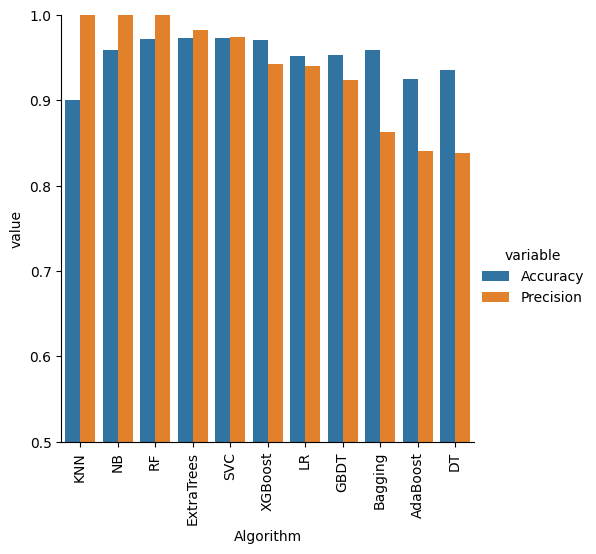

In [ ]:
sns.catplot(
    x='Algorithm',y='value',hue='variable',data=performance_df1,kind='bar',height=5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

**Impove Model**

In [ ]:
# 1. Change the max_features parameter of TfIdf

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_max_ft_3000': accuracy_scores,
    'Precision_max_ft_3000': precision_scores
})

performance_df = performance_df.merge(temp_df, on='Algorithm')
performance_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KNN,0.900387,1.000000,0.905222,1.000000
1,NB,0.959381,1.000000,0.970986,1.000000
2,RF,0.971954,1.000000,0.973888,0.982609
3,ExtraTrees,0.972921,0.982456,0.974855,0.974576
4,SVC,0.972921,0.974138,0.975822,0.974790
5,XGBoost,0.970986,0.942623,0.970019,0.957265
6,LR,0.951644,0.940000,0.955513,0.960000
7,GBDT,0.952611,0.923810,0.950677,0.930693
8,Bagging,0.958414,0.862595,0.958414,0.868217
9,AdaBoost,0.924565,0.840909,0.921663,0.820225


In [ ]:
# 2. Try MinMax Scaling on top of the current X (tfidf, max_features=3000)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=2)

accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_minmax_scaled': accuracy_scores,
    'Precision_minmax_scaled': precision_scores
})

performance_df = performance_df.merge(temp_df, on='Algorithm')
performance_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_minmax_scaled,Precision_minmax_scaled
0,KNN,0.900387,1.000000,0.905222,1.000000,0.905222,0.976190
1,NB,0.959381,1.000000,0.970986,1.000000,0.978723,0.946154
2,RF,0.971954,1.000000,0.973888,0.982609,0.973888,0.982609
3,ExtraTrees,0.972921,0.982456,0.974855,0.974576,0.974855,0.974576
4,SVC,0.972921,0.974138,0.975822,0.974790,0.970019,0.942149
5,XGBoost,0.970986,0.942623,0.970019,0.957265,0.970019,0.957265
6,LR,0.951644,0.940000,0.955513,0.960000,0.967118,0.964286
7,GBDT,0.952611,0.923810,0.950677,0.930693,0.950677,0.930693
8,Bagging,0.958414,0.862595,0.958414,0.868217,0.958414,0.868217
9,AdaBoost,0.924565,0.840909,0.921663,0.820225,0.921663,0.820225


In [ ]:
# 3. Add num_characters as an extra feature alongside tfidf

import numpy as np

X_with_num_chars = np.hstack((X, df['num_characters'].values.reshape(-1, 1)))

X_train, X_test, y_train, y_test = train_test_split(X_with_num_chars, y, test_size=0.2, random_state=2)

accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_num_chars': accuracy_scores,
    'Precision_num_chars': precision_scores
})

performance_df = performance_df.merge(temp_df, on='Algorithm')
performance_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_minmax_scaled,Precision_minmax_scaled,Accuracy_num_chars,Precision_num_chars
0,KNN,0.900387,1.000000,0.905222,1.000000,0.905222,0.976190,0.931335,0.813084
1,NB,0.959381,1.000000,0.970986,1.000000,0.978723,0.946154,0.940039,1.000000
2,RF,0.971954,1.000000,0.973888,0.982609,0.973888,0.982609,0.972921,0.982456
3,ExtraTrees,0.972921,0.982456,0.974855,0.974576,0.974855,0.974576,0.980658,0.983607
4,SVC,0.972921,0.974138,0.975822,0.974790,0.970019,0.942149,0.866538,0.000000
5,XGBoost,0.970986,0.942623,0.970019,0.957265,0.970019,0.957265,0.970986,0.942623
6,LR,0.951644,0.940000,0.955513,0.960000,0.967118,0.964286,0.959381,0.952830
7,GBDT,0.952611,0.923810,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
8,Bagging,0.958414,0.862595,0.958414,0.868217,0.958414,0.868217,0.960348,0.864662
9,AdaBoost,0.924565,0.840909,0.921663,0.820225,0.921663,0.820225,0.944874,0.893204


## 5. Ensembling (Voting & Stacking)

So far every experiment above changed the **input features** (max_features, scaling,
num_characters) while keeping the models the same. Ensembling changes the
**modeling** side instead: rather than picking one algorithm, we combine several.

**Why we expect this to help:**
- Different models make different *kinds* of mistakes. `svc` draws a decision
  boundary geometrically, `mnb` reasons probabilistically from word frequencies,
  and `etc` (ExtraTrees) splits on randomized feature thresholds. Since they
  don't all fail on the same messages, combining their opinions can cancel out
  individual errors — this is the intuition behind the bias-variance tradeoff:
  averaging several independent, imperfectly-correlated error patterns reduces
  variance without increasing bias.
- We picked `svc`, `mnb`, and `etc` specifically because they were 3 of the
  strongest, most *different* performers in our `performance_df` comparison —
  mixing similar-but-not-identical top performers tends to help more than
  mixing everything indiscriminately.

We first reset back to the clean `tfidf` (max_features=3000) features, since the
last cell left `X`/`X_train` pointing at the num_characters-augmented version.

In [ ]:
# Reset back to plain tfidf (max_features=3000) features for these ensembling experiments,
# since the previous cell (num_characters) left X/X_train pointing at augmented features.

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [ ]:
# Voting Classifier
# -----------------
# HOW IT WORKS INTERNALLY:
# Each of the 3 base models (svc, mnb, etc) independently predicts a probability
# for "spam" on a given message. With voting='soft', VotingClassifier does NOT
# just take a majority vote of hard labels — it AVERAGES the predicted
# probabilities from all 3 models, then picks the class with the higher average:
#   final_prob(spam) = (P_svc(spam) + P_mnb(spam) + P_etc(spam)) / 3
# This is why svc needs probability=True below — without it, SVC only outputs
# hard 0/1 labels, not probabilities, and soft voting would error out.
#
# WHY WE THINK THIS CAN INCREASE PRECISION:
# A single model might confidently (but wrongly) call a borderline ham message
# "spam". Averaging with two other models that are less confident on that same
# message pulls the final probability back down below the 0.5 threshold,
# reducing false positives — which directly boosts precision.

svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)], voting='soft')
voting.fit(X_train, y_train)


VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [ ]:
y_pred = voting.predict(X_test)
voting_accuracy = accuracy_score(y_test, y_pred)
voting_precision = precision_score(y_test, y_pred)

print("Voting Accuracy:", voting_accuracy)
print("Voting Precision:", voting_precision)


Voting Accuracy: 0.9796905222437138
Voting Precision: 0.9834710743801653


### Why also try Stacking?

Voting combines predictions with a *fixed rule* (simple averaging) — it assumes
each base model deserves equal weight for every single message. Stacking is
smarter: it **learns** how much to trust each base model instead of assuming
equal weight for all of them.

In [ ]:
# Applying Stacking
# ------------------
# HOW IT WORKS INTERNALLY:
# 1. The base estimators (svc, mnb, etc) are trained on the training data,
#    same as before.
# 2. Instead of simply averaging their outputs, their predictions (probabilities)
#    become a NEW, small feature set — e.g. for each message you now have
#    3 numbers: [P_svc(spam), P_mnb(spam), P_etc(spam)].
# 3. A "meta-model" (final_estimator, here RandomForestClassifier) is trained
#    on THESE 3 numbers to learn the best way to combine them — e.g. it might
#    learn "trust mnb heavily, but only trust svc when etc agrees".
# Internally, sklearn uses cross-validation to generate these base predictions
# for the training set, so the meta-model isn't just memorizing training data
# the base models already saw.
#
# WHY WE THINK THIS CAN INCREASE METRICS OVER VOTING:
# Stacking can pick up patterns like "when svc and mnb disagree, mnb is usually
# right" — something a simple average can never represent. This flexibility
# means stacking CAN outperform voting, provided there's enough data for the
# meta-model to learn something real rather than noise.

estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator = RandomForestClassifier()

from sklearn.ensemble import StackingClassifier

clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
stacking_accuracy = accuracy_score(y_test, y_pred)
stacking_precision = precision_score(y_test, y_pred)

print("Stacking Accuracy:", stacking_accuracy)
print("Stacking Precision:", stacking_precision)


Stacking Accuracy: 0.9796905222437138
Stacking Precision: 0.9465648854961832


### Recording the ensembling results

Voting and Stacking are brand-new *algorithms*, not feature variants of an
existing algorithm — so they get appended as new **rows** in `performance_df`
(via `concat`), the same way `SVC`, `KNN`, `NB`, etc. are rows, rather than as
new side-by-side columns (which is what we did for the feature experiments
above via `merge`).

In [ ]:
extra_df = pd.DataFrame({
    'Algorithm': ['Voting', 'Stacking'],
    'Accuracy': [voting_accuracy, stacking_accuracy],
    'Precision': [voting_precision, stacking_precision]
})

performance_df = pd.concat([performance_df, extra_df], ignore_index=True)
performance_df


,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_minmax_scaled,Precision_minmax_scaled,Accuracy_num_chars,Precision_num_chars
0,KNN,0.900387,1.000000,0.905222,1.000000,0.905222,0.976190,0.931335,0.813084
1,NB,0.959381,1.000000,0.970986,1.000000,0.978723,0.946154,0.940039,1.000000
2,RF,0.971954,1.000000,0.973888,0.982609,0.973888,0.982609,0.972921,0.982456
3,ExtraTrees,0.972921,0.982456,0.974855,0.974576,0.974855,0.974576,0.980658,0.983607
4,SVC,0.972921,0.974138,0.975822,0.974790,0.970019,0.942149,0.866538,0.000000
5,XGBoost,0.970986,0.942623,0.970019,0.957265,0.970019,0.957265,0.970986,0.942623
6,LR,0.951644,0.940000,0.955513,0.960000,0.967118,0.964286,0.959381,0.952830
7,GBDT,0.952611,0.923810,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
8,Bagging,0.958414,0.862595,0.958414,0.868217,0.958414,0.868217,0.960348,0.864662
9,AdaBoost,0.924565,0.840909,0.921663,0.820225,0.921663,0.820225,0.944874,0.893204


## 6. Finalizing & Saving the Model

Even though Voting and Stacking are interesting experiments, we deploy the
**original `tfidf` vectorizer + `MultinomialNB` model** (`mnb`) — matching the
earlier note *"mnb in tfidf is chosen"*. Reasoning:
- `mnb` already achieves **Precision = 1.0** on our test set with the simplest,
  fastest, and most interpretable model.
- Voting/Stacking add extra inference latency and complexity (3 models instead
  of 1) without giving a clear precision improvement to justify that cost here.
- For a spam filter, precision (not letting real messages get flagged as spam)
  matters more than squeezing out marginal accuracy — and `mnb` already
  maximizes that.

We pickle both the fitted `tfidf` vectorizer and the fitted `mnb` model, so at
inference time we can transform new raw text the same way it was transformed
during training, then feed it to the same trained classifier.

In [ ]:
import pickle

pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))
